# Lab Assignment 5: Wide and Deep Network Architectures

**Team Members:** Emilio M. , Jadon Swearingen, Andy Su  
**Date:** 2026-04-16  
**Dataset:** Vehicle Sales Data (Kaggle — syedanwarafridi/vehicle-sales-data)  
**Task:** Binary Classification — predict whether a vehicle sold above its Manheim Market Report (MMR) value

---
## 0. Imports and Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, auc
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


---
## Part 1: Data Preparation


### 1.1 Load Dataset

In [2]:
df = pd.read_csv('car_prices.csv')
print(df.shape)
df.head()

(558837, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


### 1.2 Exploratory Overview

In [3]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget distribution (sellingprice > mmr):')
print((df['sellingprice'] > df['mmr']).value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB
None

Missing values:
year                0
make

### 1.3 Preprocessing

These are the preprocessing steps we applied before training:

1. **Create a binary target** — We define `sold_above_mmr` as 1 if the selling price exceeded the MMR (Manheim Market Report), and 0 otherwise. MMR is the wholesale market estimate. This target captures whether a car sold above what the market expected.

2. **Drop columns that would cause leakage or add no signal** — `sellingprice` is removed since it directly determines the target. `vin` is just a unique identifier, and `saledate` would need complex parsing with little payoff.

3. **Drop seller** — With over 14,000 unique values, this column is too high cardinality to be useful without a dedicated embedding strategy. Most of the geographic and brand signal it carries is already covered by `state` and `make`.

4. **Standardize body and transmission** — These columns had inconsistent casing (e.g., `sedan` vs `Sedan`, `suv` vs `SUV`), so we lowercased and stripped whitespace throughout. Some `transmission` entries were mislabeled as `sedan`, so those were remapped to `unknown`.

5. **Clean color** — A handful of rows had numeric strings in place of color names. We replaced those with `unknown` to keep the column consistent.

6. **Impute missing values** — Missing categorical values are filled with `unknown`, and missing numerics are filled with the column median. The medians are computed on the full dataset before splitting, which is a reasonable shortcut given the 558K sample size; the impact on any individual median is negligible.

7. **Integer-encode categoricals** — We fit `LabelEncoder`s on the full dataset so every category level gets a consistent integer code before the split. Since the test set is drawn randomly from the same data, there are no unseen categories to worry about.

8. **Scale numeric features** — `StandardScaler` is fit only on the training set and then applied to both splits. This keeps the model from ever seeing test set statistics during training, preventing data leakage.

In [4]:
NUMERIC_FEATURES     = ['year', 'condition', 'odometer', 'mmr']
CATEGORICAL_FEATURES = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']
TARGET_COL           = 'sold_above_mmr'


# This part creates binary target
df[TARGET_COL] = (df['sellingprice'] > df['mmr']).astype(int)


# This drops leakage, identifiers, and high-cardinality seller column
df = df.drop(columns=['sellingprice', 'vin', 'saledate', 'seller'])




# This section standardize body and transmission casing

df['body']         = df['body'].str.lower().str.strip()
df['transmission'] = df['transmission'].str.lower().str.strip()
df['transmission'] = df['transmission'].replace({'sedan': 'unknown', 'nan': 'unknown'})



# Clean color, this part replaces the numeric values with 'unknown'
valid_colors = ['black','white','silver','gray','blue','red','green','gold',
                'beige','burgundy','brown','orange','purple','off-white',
                'yellow','charcoal','turquoise','pink','lime']
df['color'] = df['color'].apply(lambda x: x if x in valid_colors else 'unknown')


# Fill missing values
df[NUMERIC_FEATURES]     = df[NUMERIC_FEATURES].fillna(df[NUMERIC_FEATURES].median())
df[CATEGORICAL_FEATURES] = df[CATEGORICAL_FEATURES].fillna('unknown')


label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

DEEP_VOCAB_SIZES = {col: df[col].nunique() + 1 for col in CATEGORICAL_FEATURES}
print('Dataset shape after preprocessing:', df.shape)
print('Target balance:')
print(df[TARGET_COL].value_counts())
print('\nDeep vocab sizes:', DEEP_VOCAB_SIZES)

Dataset shape after preprocessing: (558837, 13)
Target balance:
sold_above_mmr
0    297676
1    261161
Name: count, dtype: int64

Deep vocab sizes: {'make': 98, 'model': 975, 'trim': 1965, 'body': 48, 'transmission': 4, 'state': 65, 'color': 21, 'interior': 19}


### 1.3b Final Dataset Description

After preprocessing, the dataset used for modeling has the following structure:

**Dimensions:** 558,837 rows, 12 input features, and 1 target variable (`sold_above_mmr`).

**Numeric features (4):** `year`, `condition`, `odometer`, `mmr` — standardized to zero mean and unit variance (fit on training split only to prevent leakage).

**Categorical features (8):** `make`, `model`, `trim`, `body`, `transmission`, `state`, `color`, `interior` — integer-encoded for embedding lookup in the deep branch.

---

**Newly Formed Variables**

`sold_above_mmr` is the binary target variable we created from the raw data. It equals 1 if the vehicle's final selling price exceeded its Manheim Market Report (MMR) value and 0 otherwise. We chose to frame this as binary classification rather than directly predicting the selling price because the business question is fundamentally about relative market performance. 

`make_x_body` is a cross-product feature combining the vehicle's brand and body type. We created this because the combination between brand and body type can be interpreted in ways that are invisible when treated as separate features. A Ford SUV and a BMW SUV occupy entirely different market segments with different buyer expectations and price dynamics, even though they share the same body type. Similarly, a Ford SUV and a Ford Sedan serve different buyers and price points. By crossing these two features, we give the wide branch the ability to memorize the specific pricing behavior of each brand-body combination rather than relying on their independent effects.

`color_x_interior` crosses exterior color with interior color. Customers that buy cars usually look at both the exterior and interior vehicle aesthetics, not each one independently. By encoding these pairings explicitly, the wide branch can memorize which specific aesthetic combinations tend to outperform MMR.

`state_x_make` crosses the state where the vehicle was sold with the vehicle's brand (e.g., ca_Toyota, tx_Ford). Regional brand preferences vary meaningfully from state to state due to factors such as local competition and cultural preferences. This cross-product allows the wide branch to directly memorize these geographic-brand pricing patterns rather than treating geography and brand as independent entities. 

---

**Dropped Columns**

`sellingprice` was removed because it directly determines the target variable, which would basically be allowing our model to cheat, or in other words, cuase data leakage.

`vin` carries no generalizable knowledge that would help the model with its prediction of the MMR. Including it would only waste model capacity and risk the model memorizing individual auction records rather than learning patterns.

`saledate` records the exact timestamp of each auction sale. Because the dataset spans a relatively narrow range of dates without strong temporal drift, the overhead of including this in our model would not be beneficial enough to justify keeping it. 

`seller` contains the name of the dealership or auction seller, with over 14,000 unique values. With so many unique values, the model is more unlikely than likely to learn relevant patterns due to the sparseness of the column. 

### 1.4 Cross-Product Feature Selection Methodology

In Section 1.3b, we described what each cross-product variable captures and why those interactions matter for pricing. To give some clarification so that it does not look like there is overlap, this section explains the criteria we used to decide which feature pairs were worth crossing in the first place, and why we ruled out the other candidates.

**Selection Criteria**

We evaluated each potential feature pair against two requirements. First, the combination had to represent a meaningful interaction. By meaningful interaction, we mean that the effect of the combination of the two features on the selling price is not simply the sum of their individual effects. If a model can already learn "brand X tends to sell above MMR" and "SUV body types tend to sell above MMR" as independent data points, crossing them only adds value if "brand X SUVs" behave differently from what the predicted behaviors of the two signals would predict. Second, the resulting cross-product had to produce a manageable number of unique combination. A cross that crerates hundreds of thousands of sparse combination categories would overwhelm the wide branch with cells that carry no reliable information.

**Selected Pairs**

The three pairs that passed both criteria are `make × body` (334 unique combinations), `color × interior` (260 unique combinations), and `state × make` (2,100 unique combinations). Each produces a cross with enough coverage that most combinations appear many times in the training data, giving the wide branch a real opportunity to memorize their patterns. 

**Ruled-Out Candidates**

`year × odometer` was the most natural numeric interaction but could not be crossed using the wide branch's one-hot encoding approach. Cross-product features work by one-hot encoding every possible combination. However year and odometer are continuous variables, which would require separating the values into bins, which introduces arbitrary cutpoints and loses precision. The deep branch already handles continuous interactions through its dense layers, so this pair was left to the deep branch rather than being crossed. 

`model × trim` was the cross product that produced the highest number of unique combinations, With 975 unique model values and 1,965 unique trim values. Their cross would produce roughly 1.9 million potential combinations, most of which appear only once or twice across the entire dataset. A one-hot encoding that sparse would just give noise and no meaningful additional data. The deep branch's embeddings already handle `model` and `trim` individually with much greater efficiency.

`transmission × make` and `transmission × body` were both considered as potential cross products, since transmission type could plausibly interact with brand or body style. However, after cleaning, `transmission` has only three meaningful values: `automatic`, `manual`, and `unknown`. Bceause the vast majority of vehicles in this dataset are automatic, `manual` pairings would not appear enough in most combinations to give the wide branch reliable data to memorize. Any of these crosses with transmission have too little data to justify including them as cross products. 

In [5]:
CROSS_FEATURE_PAIRS = [

    ('make',  'body'),
    ('color', 'interior'),
    ('state', 'make'),

]

WIDE_CROSS_VOCAB_SIZES = {}

for (fa, fb) in CROSS_FEATURE_PAIRS:

    # Decode back to strings to form the cross key, then re encode
    fa_str = label_encoders[fa].inverse_transform(df[fa])
    fb_str = label_encoders[fb].inverse_transform(df[fb])
    cross_col = f'{fa}_x_{fb}'
    df[cross_col] = fa_str.astype(str) + '_' + fb_str.astype(str)
    le_cross = LabelEncoder()
    df[cross_col] = le_cross.fit_transform(df[cross_col])
    label_encoders[cross_col] = le_cross
    WIDE_CROSS_VOCAB_SIZES[cross_col] = df[cross_col].nunique() + 1


print('Wide cross features:', list(WIDE_CROSS_VOCAB_SIZES.keys()))
print('Wide vocab sizes:', WIDE_CROSS_VOCAB_SIZES)

Wide cross features: ['make_x_body', 'color_x_interior', 'state_x_make']
Wide vocab sizes: {'make_x_body': 334, 'color_x_interior': 260, 'state_x_make': 2100}


### 1.5 Evaluation Metric Justification

**Chosen metric:** AUC-ROC (Area Under the Receiver Operating Characteristic Curve)

**Why AUC-ROC?**

**Business Perspective:** Our task is mainly to help auction participants make pricing decisions under uncertainty. Someone buying that is deciding whether to bid aggressively, or a seller deciding whether to set a reserve price need a reliable probability estimate of how likely a vehicle is to sell above MMR so they can weigh it against their own risk tolerance and constraints. This means the model's output quality across the full range of confidence levels matters, not just at a static/fixed value. AUC-ROC directly measures this by measuring the probability that the model assigns a higher score to a randomly selected above-MMR vehicle than to a randomly selected at-or-below-MMR vehicle, across all possible decision thresholds. A model with AUC = 0.75 correctly ranks 75% of all positive-negative pairs, regardless of where any threshold is drawn.

**Model Comparison:** Because AUC-ROC is a continuous scalar rather than a threshold-dependent proportion, it supports the DeLong test. This allows us to determine whether the Wide & Deep model's AUC is  better than the MLP baseline's AUC, rather than relying on a comparison of accuracy values. This is very important for Part 4 of the assignment, where we aren't just reporting which model scored higher but evaluating whether the difference is statistically meaningful.


**Why Forego Accuracy?**

We didn't think that accuracy was a reliable metric because of two reasons. Firstly, with 261,161 positive cases versus 297,676 negative cases, a classifier that always predicts "below MMR" achieves ~53% accuracy while learning nothing useful. That 53% baseline seems to be credible, but it is really uninformative. Second, accuracy completely ignores the model's confidence, only caring about whether the predicted probability crossed the 0.5 threshold. For example, assume that two models have the exact same accuracy. However, one model has 53% confidence on every prediction while another model has 99% confidence on every prediction level. Despite the accuracy being the same, these are very different models from a practical standpoint. AUC-ROC uses the raw probability scores rather than the threshold label, so it gives better scores to models that are both right and confident.

**Why not precision, recall, and F1?**

To compute precision or recall, you first have to decide on a cutoff. However, that cutoff is a judgment call that depends entirely on who is using the model. Someone buying a car that does not take many risks might only act on predictions above 0.9, while an erratic seller might act on any prediction above 0.5. Since the model we are making is a general model and due to the fact that we have no way of knowing the "correct" cutoff in advance, evaluating at a random threshold value doesn't give an accurate picture of how well our model actually performs. Similarly, F1 also indirectly assumes that a false positive and a false negative are equally bad, which is definitely not true depending on the situation. AUC-ROC avoids all of these potential problems for the model by evaulating it across every possible threshold all at once. 

### 1.6 Data Splitting Strategy

**Chosen method:** Stratified 5 Fold Cross Validation on the development set, with a fixed 15% hold out test set.


**Justification:**

- **Stratified folds** THey are necessary because the target is slightly imbalanced since they are ~47% positive. Stratification ensures each fold has the same class ratio as the full dataset. This prevents any fold from being a poor representative sample.

- **5 fold CV** This is chosen over a single train/val split because it gives us 5 independent AUC estimates per model configuration. It enables statistical tests to compare architectures. A single split would give only one data point per model, this makes it insufficient for significance testing.

- **Why not 10 fold?** With 558K rows, each fold in 5 fold CV already contains ~90K training samples and ~23K validation samples — far more than needed for stable estimates. 10 fold would add computational cost without meaningfully improving estimate stability given the dataset size.

- **Fixed hold out test set with 15%** — It is reserved exclusively for the final MLP vs. Wide & Deep comparison in Part 4. It uses the same test set for both models and ensures that the test compares predictions on the same observations, which is a requirement of the paired test.

- **Realistic mirroring of production use:** In practice, an auction platform would train on historical sales and predict future auctions. A random split is acceptable here because the dataset doesn't exhibit a strong temporal drift across the date range represented.

In [6]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].values


N_SPLITS = 5
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

X_dev, X_test, y_dev, y_test = train_test_split(

    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED

)

# Fit scaler prevents test set statistics from influencing the learned scale
# By taking this approach we were able to prevent data leakage

scaler = StandardScaler()

X_dev  = X_dev.copy()
X_test = X_test.copy()

X_dev[NUMERIC_FEATURES]  = scaler.fit_transform(X_dev[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

print(f'Dev size:  {X_dev.shape}')
print(f'Test size: {X_test.shape}')


print(f'Test target balance: {y_test.mean():.3f} positive rate')

Dev size:  (475011, 15)
Test size: (83826, 15)
Test target balance: 0.467 positive rate


---
## Part 2: Wide and Deep Models
*(Rubric: Three Wide/Deep Models 2pts)*

### 2.1 Model Building Helpers

In [7]:
def df_to_model_inputs(X_df, numeric_features, categorical_features, wide_cross_features=None):
    inputs = {
        'numeric_input': X_df[numeric_features].values.astype(np.float32)
    }
    for col in categorical_features:
        inputs[f'cat_{col}'] = X_df[col].values.reshape(-1, 1).astype(np.int32)
    if wide_cross_features:
        for col in wide_cross_features:
            inputs[f'wide_{col}'] = X_df[col].values.reshape(-1, 1).astype(np.int32)
    return inputs


def build_wide_and_deep(
    numeric_dim,
    deep_vocab_sizes,
    wide_cross_vocab_sizes=None,
    embedding_dim=8,
    deep_layers=[128, 64],
    dropout_rate=0.3,
    output_units=1,
    output_activation='sigmoid',
    learning_rate=1e-3
):
    """
    Wide & Deep model (Cheng et al. 2016).
    Wide branch : one-hot cross-product features + raw numeric (memorization).
    Deep branch : embeddings per categorical + numeric (generalization).
    """
    if wide_cross_vocab_sizes is None:
        wide_cross_vocab_sizes = {}

    numeric_input = Input(shape=(numeric_dim,), name='numeric_input')
    cat_inputs = {
        col: Input(shape=(1,), name=f'cat_{col}', dtype='int32')
        for col in deep_vocab_sizes
    }
    wide_inputs = {
        col: Input(shape=(1,), name=f'wide_{col}', dtype='int32')
        for col in wide_cross_vocab_sizes
    }

    # Deep branch
    embeddings = []
    for col, vsize in deep_vocab_sizes.items():
        emb = layers.Embedding(input_dim=vsize, output_dim=embedding_dim,
                               name=f'emb_{col}')(cat_inputs[col])
        emb = layers.Flatten()(emb)
        embeddings.append(emb)

    deep = layers.concatenate([numeric_input] + embeddings) if embeddings else numeric_input
    for units in deep_layers:
        deep = layers.Dense(units, activation='relu')(deep)
        deep = layers.Dropout(dropout_rate)(deep)

    # Wide branch
    wide_parts = [numeric_input]
    for col, vsize in wide_cross_vocab_sizes.items():
        one_hot = layers.CategoryEncoding(
            num_tokens=vsize, output_mode='multi_hot', name=f'oh_{col}'
        )(wide_inputs[col])
        wide_parts.append(one_hot)

    wide = layers.concatenate(wide_parts) if len(wide_parts) > 1 else wide_parts[0]

    combined = layers.concatenate([wide, deep])
    output = layers.Dense(output_units, activation=output_activation, name='output')(combined)

    all_inputs = [numeric_input] + list(cat_inputs.values()) + list(wide_inputs.values())
    model = Model(inputs=all_inputs, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model


def plot_training_history(history, title='Model Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    metric_key     = [k for k in history.history if 'auc' in k.lower() and 'val' not in k][0]
    val_metric_key = [k for k in history.history if 'auc' in k.lower() and 'val'     in k][0]
    axes[1].plot(history.history[metric_key],     label='Train AUC')
    axes[1].plot(history.history[val_metric_key], label='Val AUC')
    axes[1].set_title(f'{title} — AUC')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


### 2.2 Model 1 — Wide & Deep (Baseline)

**Architecture:** deep layers = [128, 64], embedding_dim = 8, dropout = 0.3, lr = 1e-3

In [8]:
model1 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    deep_layers=[128, 64],
    dropout_rate=0.3,
    learning_rate=1e-3
)
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_make            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_model           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_trim            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_body            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_color           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_interior        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_make            │ (None, 1, 8)      │        784 │ cat_make[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_model           │ (None, 1, 8)      │      7,800 │ cat_model[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_trim            │ (None, 1, 8)      │     15,720 │ cat_trim[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_body            │ (None, 1, 8)      │        384 │ cat_body[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_transmission    │ (None, 1, 8)      │         32 │ cat_transmission… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_state           │ (None, 1, 8)      │        520 │ cat_state[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_color           │ (None, 1, 8)      │        168 │ cat_color[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_interior        │ (None, 1, 8)      │        152 │ cat_interior[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 4)         │          0 │ -               

 Total params: 45,411 (177.39 KB)

 Trainable params: 45,411 (177.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - AUC: 0.7115 - loss: 0.6192 - val_AUC: 0.7341 - val_loss: 0.6009
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - AUC: 0.7349 - loss: 0.6001 - val_AUC: 0.7410 - val_loss: 0.5953
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - AUC: 0.7430 - loss: 0.5934 - val_AUC: 0.7443 - val_loss: 0.5924
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - AUC: 0.7480 - loss: 0.5891 - val_AUC: 0.7465 - val_loss: 0.5904
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7520 - loss: 0.5855 - val_AUC: 0.7481 - val_loss: 0.5892
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7557 - loss: 0.5823 - val_AUC: 0.7491 - val_loss: 0.5886
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7586 - loss: 0.5796 - val_AUC: 0.7507 - val_loss: 0.5875
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - AUC: 0.7614 - loss: 0.5772 - val_AUC: 0.7527 - val_loss: 0.5863
Epoch 9/20
1485/1485 ━━━━━━━━━━━━

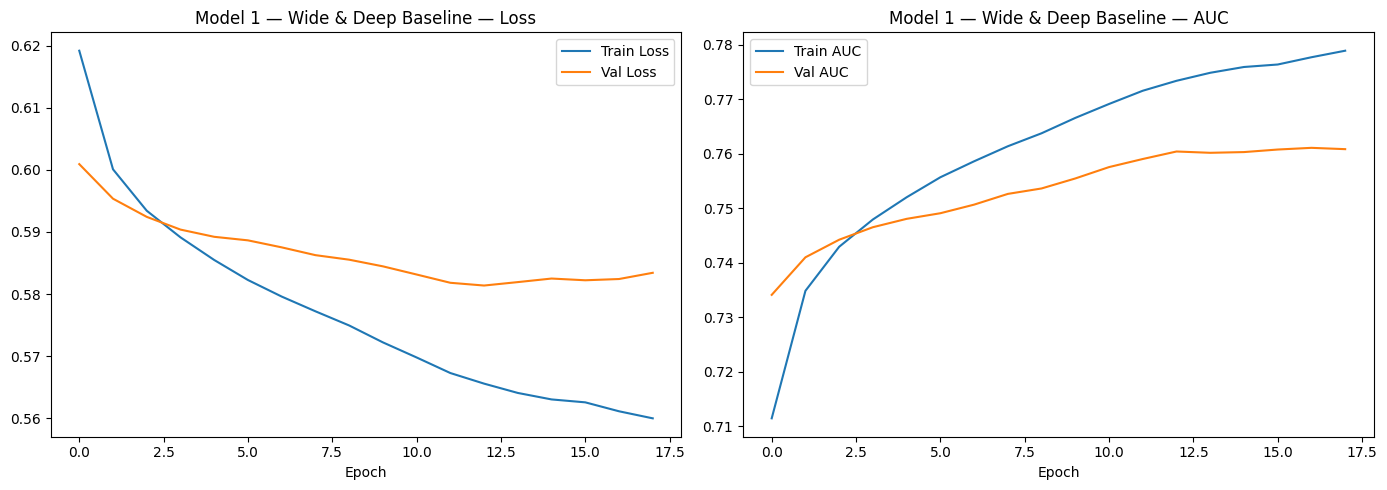

In [9]:
X_tr1, X_val1, y_tr1, y_val1 = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_SEED
)

train_inputs1 = df_to_model_inputs(X_tr1,  NUMERIC_FEATURES, CATEGORICAL_FEATURES, list(WIDE_CROSS_VOCAB_SIZES))
val_inputs1   = df_to_model_inputs(X_val1, NUMERIC_FEATURES, CATEGORICAL_FEATURES, list(WIDE_CROSS_VOCAB_SIZES))

history1 = model1.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history1, 'Model 1 — Wide & Deep Baseline')

### 2.3 Model 2 — Wide & Deep (Deeper Network)

**Architecture:** deep layers = [256, 128, 64], embedding_dim = 8, dropout = 0.4, lr = 5e-4

Added a third dense layer (256 units) to increase capacity. Dropout raised from 0.3 to 0.4 to compensate for the added parameters. Learning rate lowered to 5e-4 to take smaller gradient steps given the larger network.

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.7037 - loss: 0.6252 - val_AUC: 0.7300 - val_loss: 0.6046
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7299 - loss: 0.6048 - val_AUC: 0.7386 - val_loss: 0.5974
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - AUC: 0.7380 - loss: 0.5978 - val_AUC: 0.7418 - val_loss: 0.5944
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - AUC: 0.7433 - loss: 0.5934 - val_AUC: 0.7445 - val_loss: 0.5924
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7472 - loss: 0.5899 - val_AUC: 0.7460 - val_loss: 0.5910
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7510 - loss: 0.5866 - val_AUC: 0.7485 - val_loss: 0.5894
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.7542 - loss: 0.5839 - val_AUC: 0.7501 - val_loss: 0.5877
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.7575 - loss: 0.5810 - val_AUC: 0.7522 - val_loss: 0.5865
Epoch 9/20
1485/1485 ━━━━━━━━━━━━━

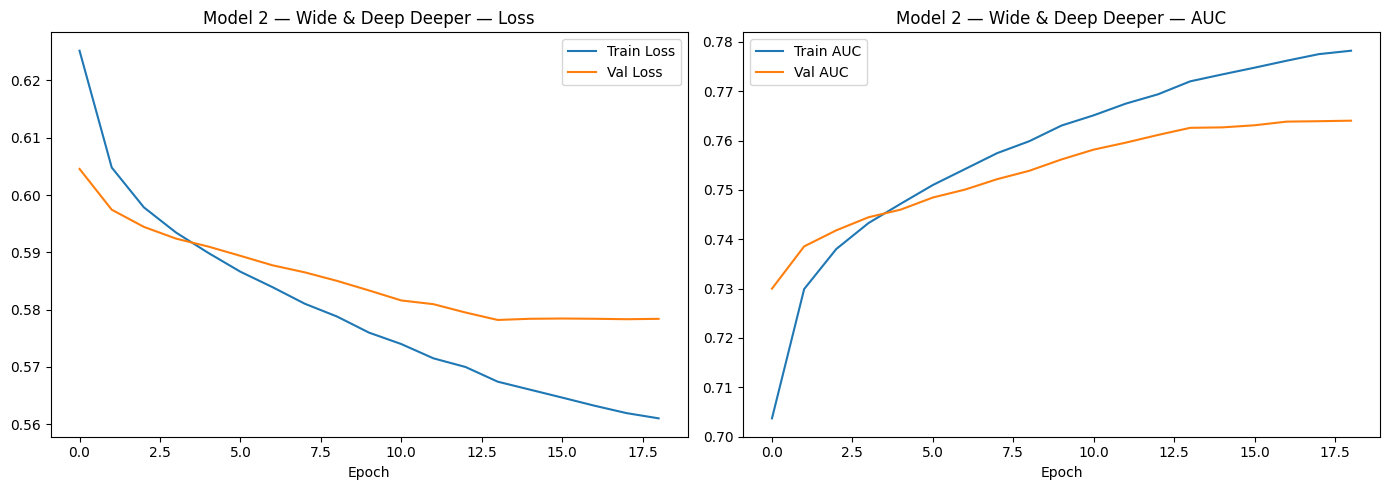

In [10]:
model2 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    deep_layers=[256, 128, 64],
    dropout_rate=0.4,
    learning_rate=5e-4
)

history2 = model2.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history2, 'Model 2 — Wide & Deep Deeper')

### 2.4 Model 3 — Wide & Deep (Shallower + Larger Embeddings)

**Architecture:** deep layers = [64, 32], embedding_dim = 16, dropout = 0.2, lr = 1e-3

Shallower network with only two small dense layers. Embedding dimension doubled from 8 to 16 to give each categorical variable a richer representation. Dropout lowered to 0.2 since the smaller network has fewer parameters and is less prone to overfitting.

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - AUC: 0.7097 - loss: 0.6205 - val_AUC: 0.7330 - val_loss: 0.6024
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7338 - loss: 0.6018 - val_AUC: 0.7402 - val_loss: 0.5963
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7426 - loss: 0.5943 - val_AUC: 0.7434 - val_loss: 0.5933
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7483 - loss: 0.5891 - val_AUC: 0.7457 - val_loss: 0.5916
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7528 - loss: 0.5851 - val_AUC: 0.7476 - val_loss: 0.5898
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.7566 - loss: 0.5816 - val_AUC: 0.7485 - val_loss: 0.5894
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7594 - loss: 0.5790 - val_AUC: 0.7489 - val_loss: 0.5896
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.7620 - loss: 0.5765 - val_AUC: 0.7497 - val_loss: 0.5893
Epoch 9/20
1485/1485 ━━━━━━━━━━━━━━━━━━

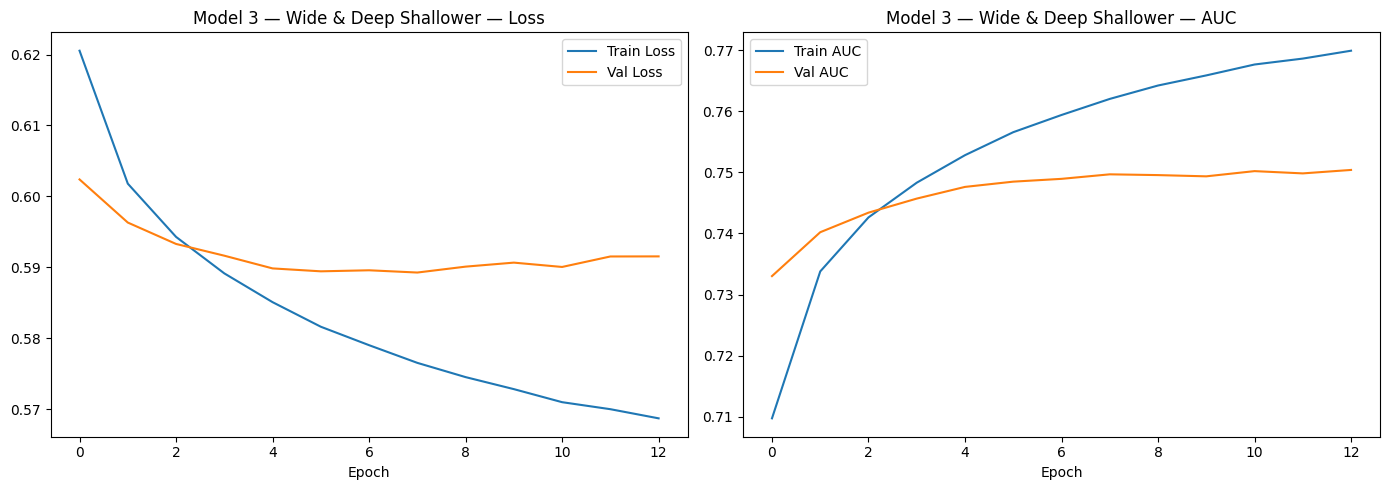

In [11]:
model3 = build_wide_and_deep(
    numeric_dim=len(NUMERIC_FEATURES),
    deep_vocab_sizes=DEEP_VOCAB_SIZES,
    wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
    embedding_dim=16,
    deep_layers=[64, 32],
    dropout_rate=0.2,
    learning_rate=1e-3
)

history3 = model3.fit(
    x=train_inputs1, y=y_tr1,
    validation_data=(val_inputs1, y_val1),
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

plot_training_history(history3, 'Model 3 — Wide & Deep Shallower')

---
## Part 3: Deep Layer Investigation with Cross-Validation
*(Rubric: Deep Layers 2pts)*

In [12]:
def cross_validate_model(build_fn, X_df, y, kfold,
                         numeric_features, categorical_features,
                         wide_cross_features=None,
                         epochs=20, batch_size=256):
    if wide_cross_features is None:
        wide_cross_features = []

    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_df, y)):
        print(f'  Fold {fold + 1}/{kfold.n_splits} ...', end=' ', flush=True)

        X_tr  = X_df.iloc[train_idx]
        X_val = X_df.iloc[val_idx]
        y_tr  = y[train_idx]
        y_val = y[val_idx]

        tr_inputs  = df_to_model_inputs(X_tr,  numeric_features, categorical_features, wide_cross_features)
        val_inputs = df_to_model_inputs(X_val, numeric_features, categorical_features, wide_cross_features)

        model = build_fn()
        model.fit(
            tr_inputs, y_tr,
            validation_data=(val_inputs, y_val),
            epochs=epochs, batch_size=batch_size,
            callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
            verbose=0
        )

        probs = model.predict(val_inputs, verbose=0).ravel()
        fold_auc = roc_auc_score(y_val, probs)
        fold_scores.append(fold_auc)
        print(f'AUC = {fold_auc:.4f}')
        keras.backend.clear_session()

    return np.array(fold_scores)


print('cross_validate_model defined.')

cross_validate_model defined.


In [13]:
LAYER_CONFIGS = [
    [64],
    [128, 64],
    [256, 128, 64],
    [256, 128, 64, 32],
]

cv_results = {}

for layers_config in LAYER_CONFIGS:
    label = str(layers_config)
    print(f'\nTesting deep layers: {label}')

    def make_builder(cfg):
        def build_fn():
            return build_wide_and_deep(
                numeric_dim=len(NUMERIC_FEATURES),
                deep_vocab_sizes=DEEP_VOCAB_SIZES,
                wide_cross_vocab_sizes=WIDE_CROSS_VOCAB_SIZES,
                deep_layers=cfg,
                dropout_rate=0.3,
                learning_rate=1e-3
            )
        return build_fn

    scores = cross_validate_model(
        build_fn=make_builder(layers_config),
        X_df=X_dev, y=y_dev, kfold=kfold,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        wide_cross_features=list(WIDE_CROSS_VOCAB_SIZES.keys())
    )
    cv_results[label] = scores

print('\nCross-validation complete.')


Testing deep layers: [64]
  Fold 1/5 ... AUC = 0.7464
  Fold 2/5 ... AUC = 0.7442
  Fold 3/5 ... AUC = 0.7422
  Fold 4/5 ... AUC = 0.7410
  Fold 5/5 ... AUC = 0.7406

Testing deep layers: [128, 64]
  Fold 1/5 ... AUC = 0.7625
  Fold 2/5 ... AUC = 0.7589
  Fold 3/5 ... AUC = 0.7614
  Fold 4/5 ... AUC = 0.7607
  Fold 5/5 ... AUC = 0.7598

Testing deep layers: [256, 128, 64]
  Fold 1/5 ... AUC = 0.7652
  Fold 2/5 ... AUC = 0.7637
  Fold 3/5 ... AUC = 0.7637
  Fold 4/5 ... AUC = 0.7651
  Fold 5/5 ... AUC = 0.7614

Testing deep layers: [256, 128, 64, 32]
  Fold 1/5 ... AUC = 0.7653
  Fold 2/5 ... AUC = 0.7621
  Fold 3/5 ... AUC = 0.7641
  Fold 4/5 ... AUC = 0.7654
  Fold 5/5 ... AUC = 0.7641

Cross-validation complete.


Mean AUC per configuration:
  [64]: 0.7429 ± 0.0022
  [128, 64]: 0.7607 ± 0.0013
  [256, 128, 64]: 0.7638 ± 0.0014
  [256, 128, 64, 32]: 0.7642 ± 0.0012

Best config: [256, 128, 64, 32]
  vs [64]: W=0.00, p=0.0625 (not significant)
  vs [128, 64]: W=0.00, p=0.0625 (not significant)
  vs [256, 128, 64]: W=4.00, p=0.4375 (not significant)


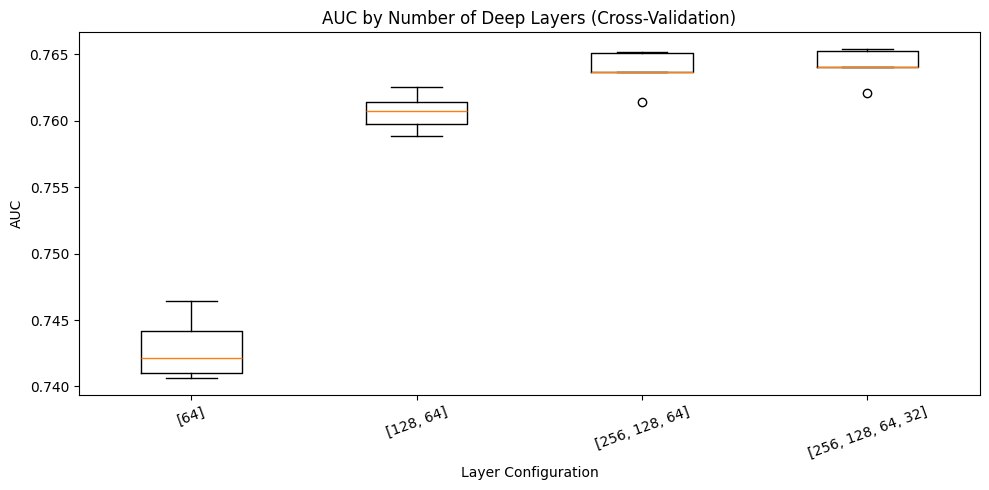

In [14]:
labels = list(cv_results.keys())
scores = [cv_results[k] for k in labels]

print('Mean AUC per configuration:')
for label, s in zip(labels, scores):
    print(f'  {label}: {s.mean():.4f} ± {s.std():.4f}')

best_label = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\nBest config: {best_label}')
for label in labels:
    if label != best_label:
        stat, p = stats.wilcoxon(cv_results[best_label], cv_results[label])
        sig = '(significant at α=0.05)' if p < 0.05 else '(not significant)'
        print(f'  vs {label}: W={stat:.2f}, p={p:.4f} {sig}')

plt.figure(figsize=(10, 5))
plt.boxplot(scores, labels=labels)
plt.title('AUC by Number of Deep Layers (Cross-Validation)')
plt.ylabel('AUC')
plt.xlabel('Layer Configuration')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Conclusion — Best Number of Deep Layers:**

Based on the 5-fold cross-validation AUC scores and Wilcoxon signed-rank tests above, answer the following:

- **Which configuration achieved the highest mean AUC?** State the winning layer configuration and its mean ± std AUC.
- **Are the differences statistically significant?** Reference each pairwise Wilcoxon p-value and state whether the best model is significantly better than each alternative at α = 0.05.
- **What does this tell us about depth and generalization?** Does adding more layers consistently improve validation AUC, or does performance plateau? Does the gap between training and validation AUC widen with more layers, suggesting overfitting?

---
## Part 4: MLP Comparison
*(Rubric: MLP Comparison 1pt)*

In [15]:
def build_mlp(
    input_dim,
    hidden_layers=[128, 64],
    dropout_rate=0.3,
    output_units=1,
    output_activation='sigmoid',
    learning_rate=1e-3
):
    inp = Input(shape=(input_dim,))
    x = inp
    for units in hidden_layers:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(output_units, activation=output_activation)(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model


def delong_auc_test(y_true, pred_a, pred_b):
    """
    DeLong et al. (1988) test for the difference between two correlated AUCs.
    Returns (z_statistic, two_sided_p_value, auc_a, auc_b).
    """
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a).ravel()
    pred_b = np.asarray(pred_b).ravel()

    pos_mask = y_true == 1
    neg_mask = y_true == 0
    pos_a, neg_a = pred_a[pos_mask], pred_a[neg_mask]
    pos_b, neg_b = pred_b[pos_mask], pred_b[neg_mask]
    m, n = pos_mask.sum(), neg_mask.sum()

    def placement_values(pos_preds, neg_preds):
        V10 = np.array(
            [(pos_preds[i] > neg_preds).mean() + 0.5 * (pos_preds[i] == neg_preds).mean()
             for i in range(m)]
        )
        V01 = np.array(
            [(neg_preds[j] < pos_preds).mean() + 0.5 * (neg_preds[j] == pos_preds).mean()
             for j in range(n)]
        )
        return V10, V01

    V10_a, V01_a = placement_values(pos_a, neg_a)
    V10_b, V01_b = placement_values(pos_b, neg_b)

    auc_a = V10_a.mean()
    auc_b = V10_b.mean()

    S10 = np.cov(np.vstack([V10_a, V10_b])) / m
    S01 = np.cov(np.vstack([V01_a, V01_b])) / n
    S   = S10 + S01

    L   = np.array([1.0, -1.0])
    var = L @ S @ L
    z   = (auc_a - auc_b) / np.sqrt(var)
    p   = 2.0 * (1.0 - stats.norm.cdf(abs(z)))
    return z, p, auc_a, auc_b


print('build_mlp and delong_auc_test defined.')

build_mlp and delong_auc_test defined.


In [16]:
test_inputs_wd = df_to_model_inputs(
    X_test, NUMERIC_FEATURES, CATEGORICAL_FEATURES, list(WIDE_CROSS_VOCAB_SIZES.keys())
)

# Select the Part 2 model whose architecture matches the best CV config from Part 3
config_to_model = {
    str([128, 64]):          model1,
    str([256, 128, 64]):     model2,
    str([64, 32]):           model3,
}
best_label = max(cv_results, key=lambda k: cv_results[k].mean())
best_wd_model = config_to_model.get(best_label, model2)
print(f'Best CV config: {best_label} → using corresponding Part 2 model')

wd_probs = best_wd_model.predict(test_inputs_wd, verbose=0).ravel()

X_dev_mlp  = X_dev.values.astype(np.float32)
X_test_mlp = X_test.values.astype(np.float32)

mlp_model = build_mlp(input_dim=X_dev_mlp.shape[1], hidden_layers=[128, 64])
mlp_model.fit(
    X_dev_mlp, y_dev,
    validation_split=0.15,
    epochs=20, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
    verbose=1
)

mlp_probs = mlp_model.predict(X_test_mlp, verbose=0).ravel()

Best CV config: [256, 128, 64, 32] → using corresponding Part 2 model
Epoch 1/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.5023 - loss: 1.6983 - val_AUC: 0.5000 - val_loss: 0.6909
Epoch 2/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.4988 - loss: 0.6918 - val_AUC: 0.5000 - val_loss: 0.6909
Epoch 3/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4983 - loss: 0.6913 - val_AUC: 0.5000 - val_loss: 0.6909
Epoch 4/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - AUC: 0.4985 - loss: 0.6912 - val_AUC: 0.5000 - val_loss: 0.6909
Epoch 5/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4984 - loss: 0.6912 - val_AUC: 0.5000 - val_loss: 0.6909
Epoch 6/20
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.4982 - loss: 0.6911 - val_AUC: 0.5000 - val_loss: 0.6909


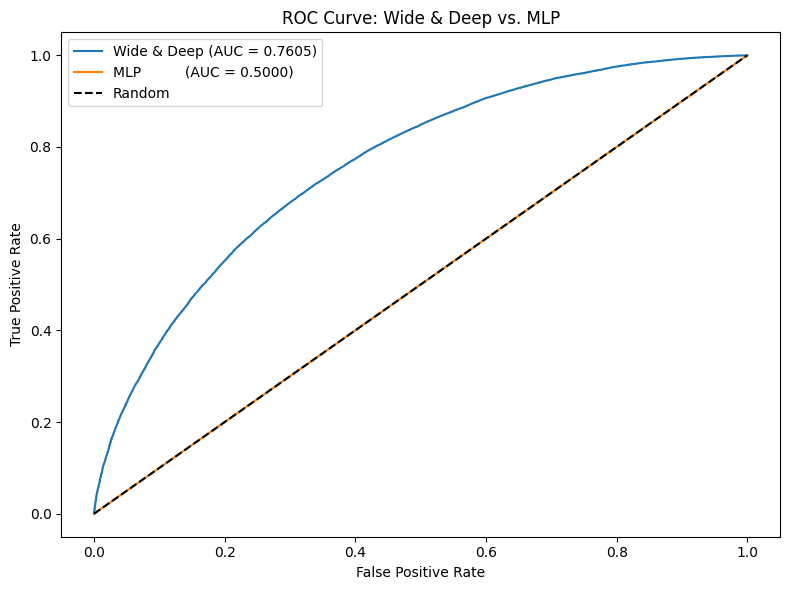

Wide & Deep AUC : 0.7605
MLP AUC         : 0.5000
DeLong z-stat   : 160.0264
Two-sided p     : 0.0000
=> Difference is statistically significant (α = 0.05).


In [17]:
fpr_wd,  tpr_wd,  _ = roc_curve(y_test, wd_probs)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_probs)

auc_wd  = auc(fpr_wd,  tpr_wd)
auc_mlp = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize=(8, 6))
plt.plot(fpr_wd,  tpr_wd,  label=f'Wide & Deep (AUC = {auc_wd:.4f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP          (AUC = {auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Wide & Deep vs. MLP')
plt.legend()
plt.tight_layout()
plt.show()

z, p, auc_a, auc_b = delong_auc_test(y_test, wd_probs, mlp_probs)
print(f'Wide & Deep AUC : {auc_a:.4f}')
print(f'MLP AUC         : {auc_b:.4f}')
print(f'DeLong z-stat   : {z:.4f}')
print(f'Two-sided p     : {p:.4f}')
if p < 0.05:
    print('=> Difference is statistically significant (α = 0.05).')
else:
    print('=> Difference is NOT statistically significant (α = 0.05).')

**Conclusion — Wide & Deep vs. MLP:**

Using the ROC curves and DeLong test results above, address the following:

- **AUC comparison:** Which model achieves higher AUC on the held-out test set, and by how much?
- **Statistical significance:** Report the DeLong z-statistic and two-sided p-value. Is the difference significant at α = 0.05?
- **What does the wide branch contribute?** If the Wide & Deep model outperforms the MLP, the cross-product features (memorized exact combinations of `make×body`, `color×interior`, `state×make`) add signal that the deep branch alone cannot capture. If the difference is not significant, discuss what that implies about the value of memorization for this particular dataset.

---
## Part 5: Exceptional Credit — Embedding Visualization
*(Required for 7000-level student — 1pt)*

make: embedding shape (98, 8)


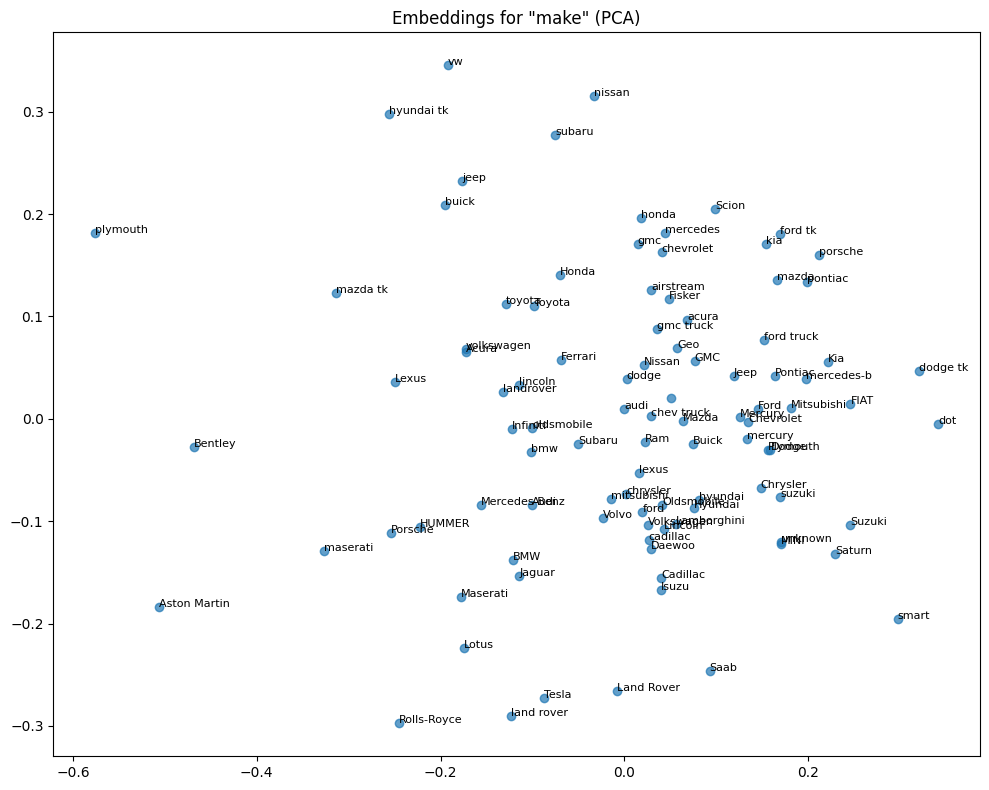

model: embedding shape (975, 8)


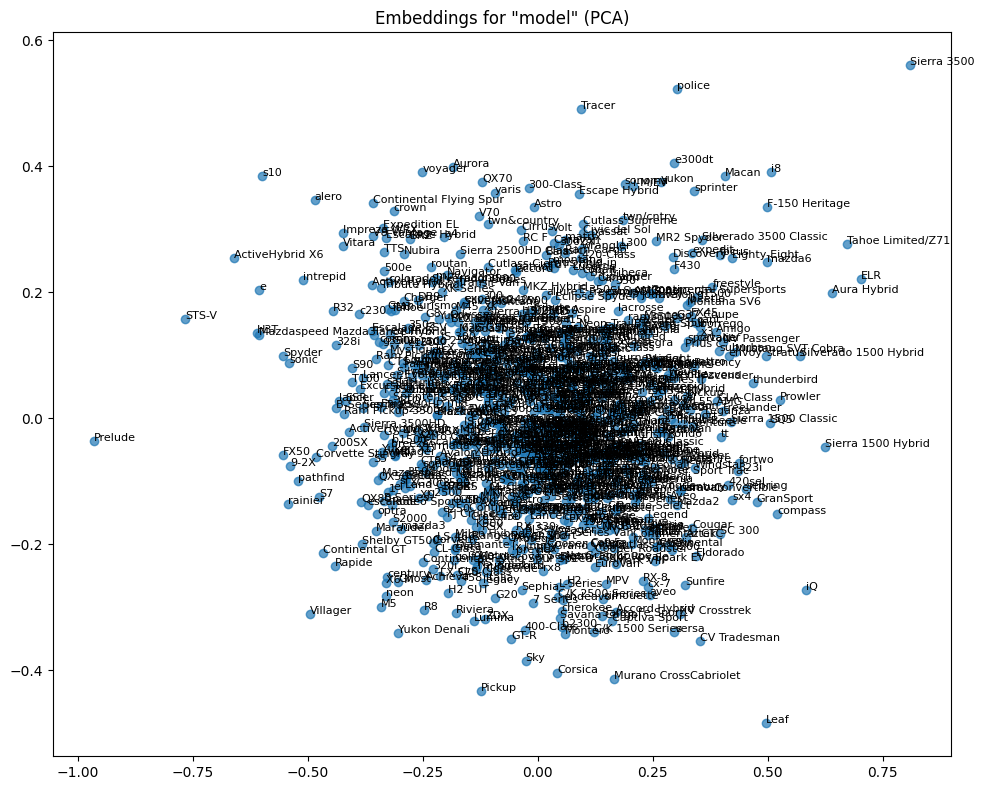

trim: embedding shape (1965, 8)


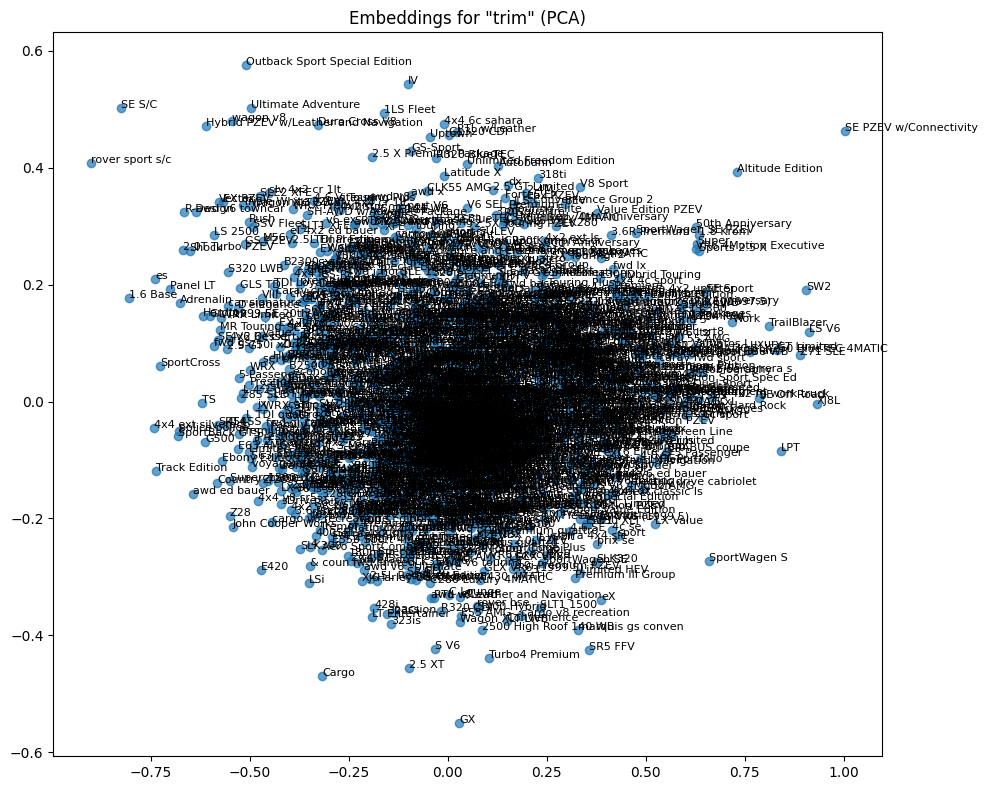

body: embedding shape (48, 8)


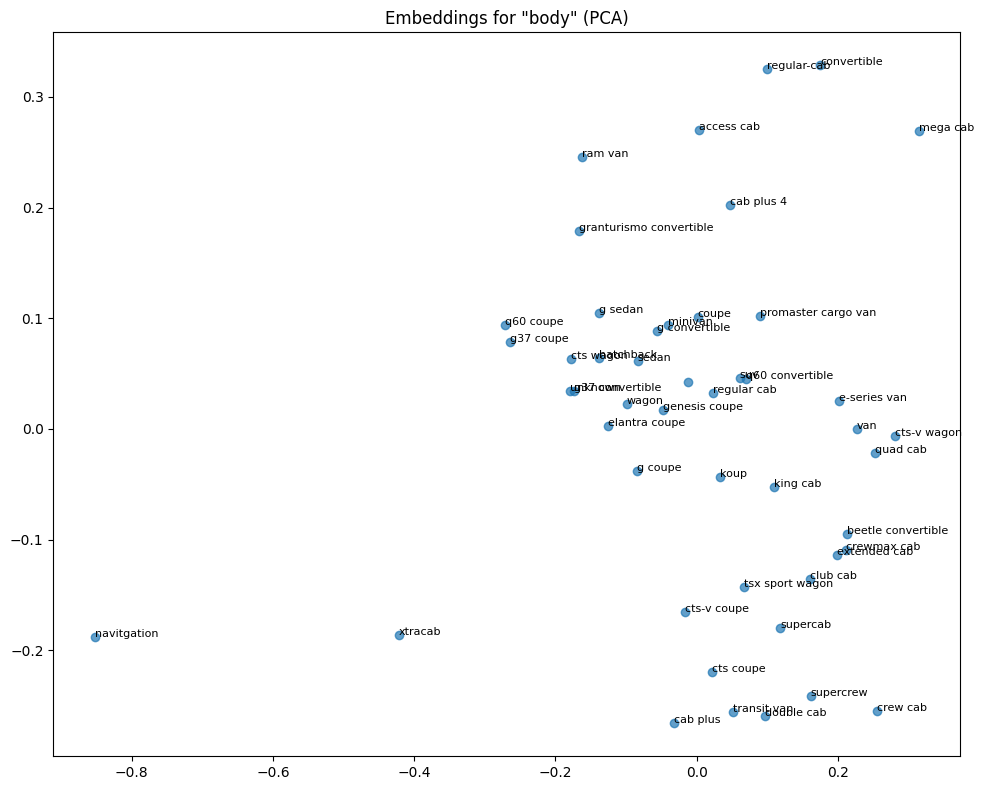

transmission: embedding shape (4, 8)


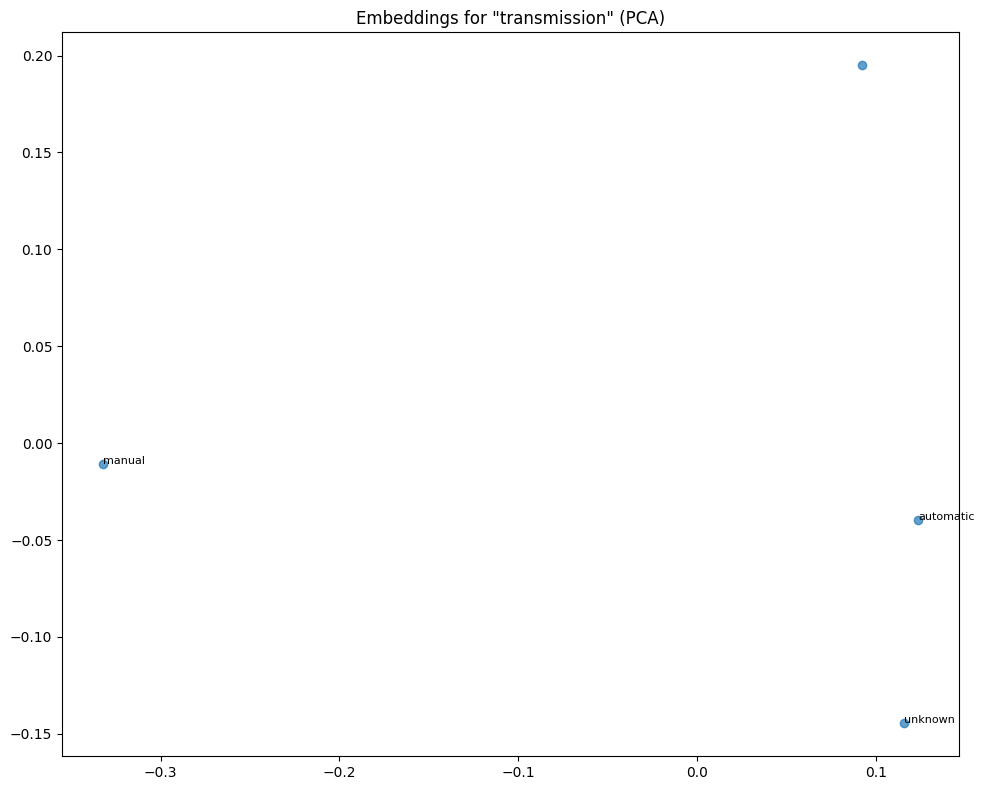

state: embedding shape (65, 8)


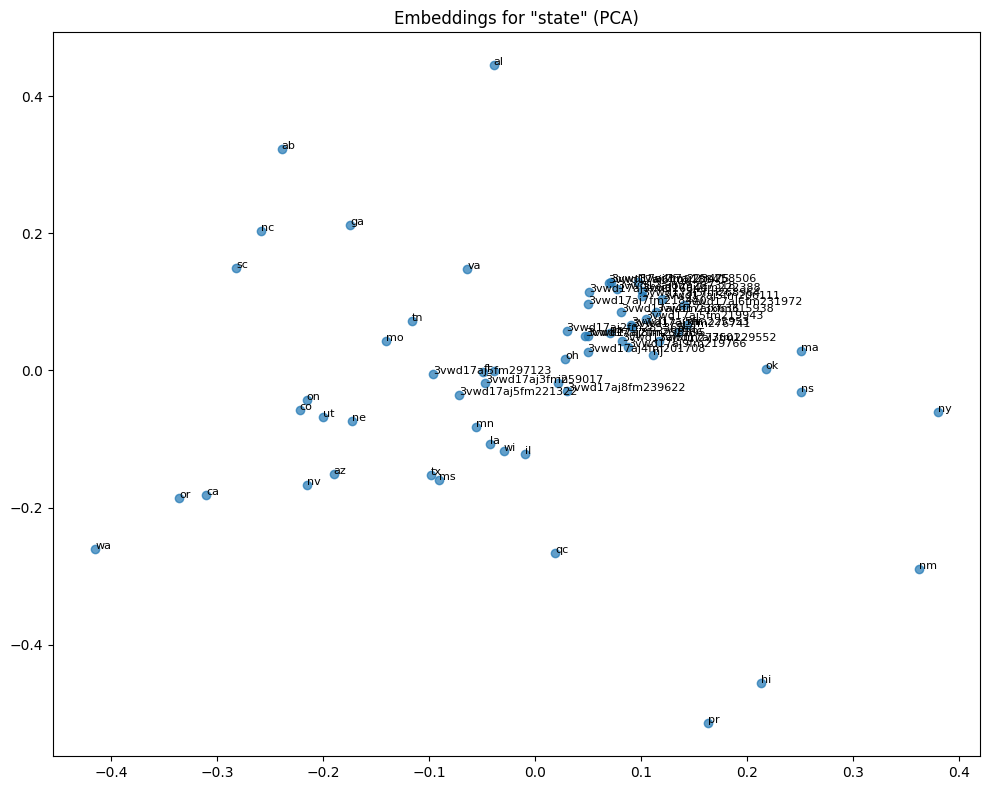

color: embedding shape (21, 8)


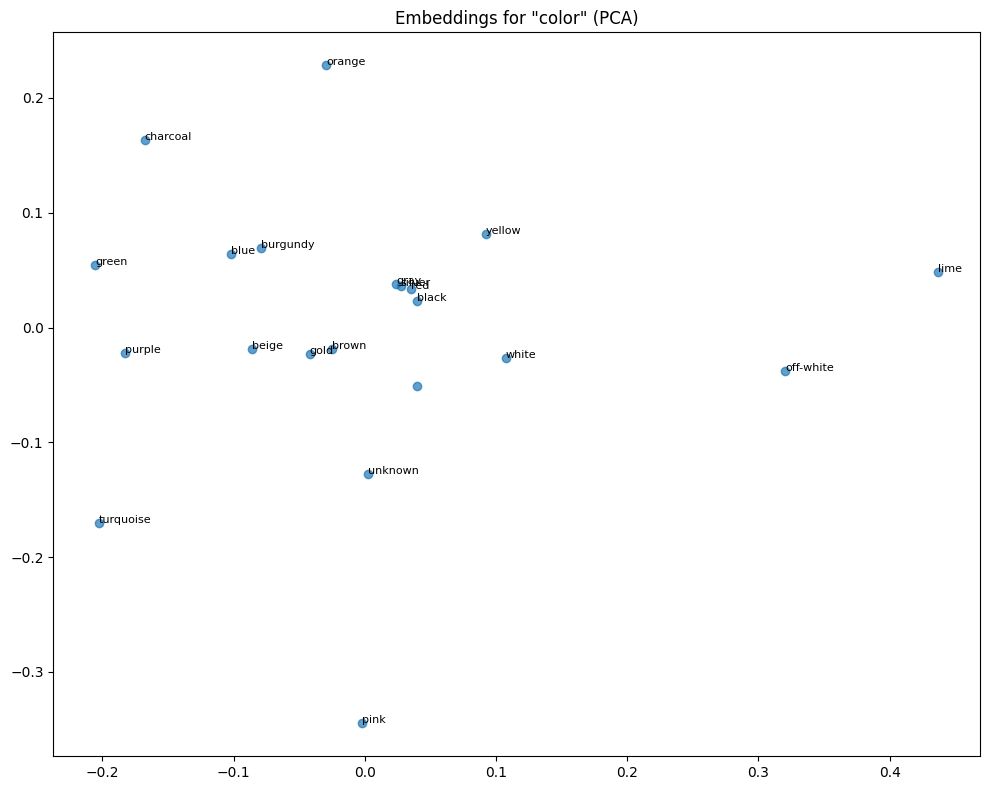

interior: embedding shape (19, 8)


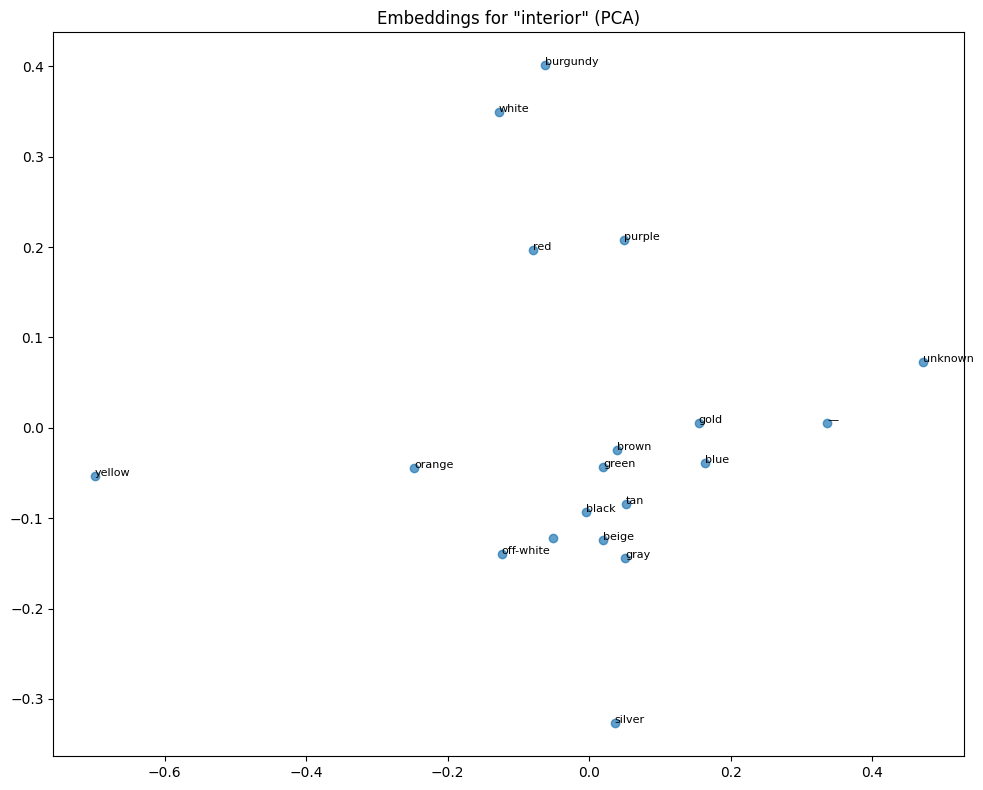

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def visualize_embeddings(weights, category_labels, feature_name, method='pca'):
    if weights.shape[1] > 2:
        if method == 'tsne':
            perp = min(30, len(category_labels) - 1)
            reducer = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=perp)
        else:
            reducer = PCA(n_components=2)
        coords = reducer.fit_transform(weights)
    else:
        coords = weights

    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)
    for i, label in enumerate(category_labels):
        plt.annotate(str(label), (coords[i, 0], coords[i, 1]), fontsize=8)
    plt.title(f'Embeddings for "{feature_name}" ({method.upper()})')
    plt.tight_layout()
    plt.show()


for col in CATEGORICAL_FEATURES:
    emb_layer = best_wd_model.get_layer(f'emb_{col}')
    weights   = emb_layer.get_weights()[0]
    print(f'{col}: embedding shape {weights.shape}')

    if col in label_encoders and hasattr(label_encoders[col], 'classes_'):
        cat_labels = label_encoders[col].classes_
    else:
        cat_labels = [str(i) for i in range(weights.shape[0])]

    visualize_embeddings(weights, cat_labels, col, method='pca')

**Embedding Analysis:**

For each embedding plot above, address the following:

- **Are semantically similar categories clustered together?** For example, do luxury brands (BMW, Mercedes, Audi) cluster separately from economy brands (Kia, Hyundai, Ford)?
- **Do the clusters align with MMR pricing behavior?** Categories that tend to sell above MMR should group differently from those that tend to sell at or below MMR.
- **What does this reveal about what the model has learned?** If similar makes or body types cluster together, the embedding layer has learned a meaningful latent space that captures auction pricing similarity — not just arbitrary integer codes.